<a href="https://colab.research.google.com/github/dianakorka/statistical_capacity/blob/main/SPI_IDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install pandas openpyxl
!pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

file_path = '/content/IDI_SPI.xlsx'
sheet_name = 'both'


df = pd.read_excel(file_path, sheet_name=sheet_name)


In [2]:
def clean_column_names(df):
    df.columns = (
        df.columns.str.strip()             # Remove leading/trailing whitespace
                 .str.lower()              # Convert to lowercase
                 .str.replace(' ', '_')    # Replace spaces with underscores
                 .str.replace(r'[^\w_]', '', regex=True)  # Remove non-alphanumeric chars
    )
    return df


In [3]:
df = clean_column_names(df)

df['itud_region'] = df['itud_region'].str.strip()  # This will remove leading/trailing whitespace, including \n
df['world_bank_income_group_2023_july'] = df['world_bank_income_group_2023_july'].str.strip()

print(df.columns)

Index(['iso3', 'itud_region', 'world_bank_income_group_2023_july', 'economy',
       'idi', 'spi', 'spi4', 'spi1', 'spi2', 'spi3', 'spi5', 'eu',
       'internet_users'],
      dtype='object')


In [4]:
# get list of income groups
df['world_bank_income_group_2023_july'].unique()

array(['Low income', 'Upper-middle income', 'Lower-middle income',
       'High income', 'n.a.'], dtype=object)

In [5]:
# Manually map categorical values to numeric values
color_mapping = {
    'n.a.': 1,
    'Low income': 2,
    'Lower-middle income': 3,
    'Upper-middle income': 4,
    'High income': 5
}

# Apply the mapping to the 'color_column'
df['world_bank_income_group_numeric'] = df['world_bank_income_group_2023_july'].map(color_mapping)

In [6]:
!pip install pycountry
import pycountry

# Create a dictionary mapping ISO3 to ISO2 codes
iso3_to_iso2 = {country.alpha_3: country.alpha_2 for country in pycountry.countries}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 45.4 MB/s eta 0:00:00


In [7]:
# Map the ISO3 codes to ISO2 codes
df['iso2'] = df['iso3'].map(iso3_to_iso2)


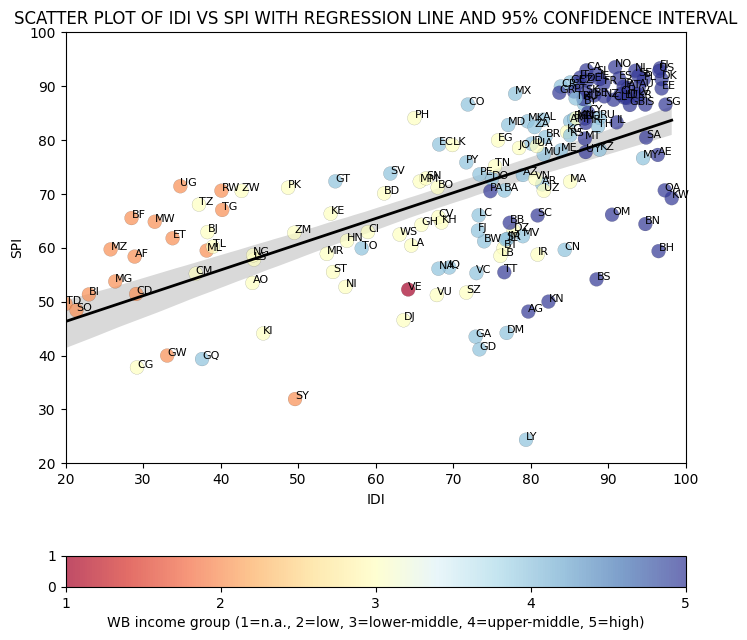

In [8]:
# version with color bar, not retained


x_column = 'idi'  # replace with your column name
y_column = 'spi'  # replace with your column name
label_column = 'iso2'  # replace with your label column
color_column = 'world_bank_income_group_numeric'  # replace with the column for colors, has to be numeric

# First, draw the scatter plot using seaborn to include the regression line
plt.figure(figsize=(8, 8))
sns.regplot(
    x=x_column, y=y_column,
    data=df,
    scatter=False,
    color='black',    # Regression line color
    line_kws={'linewidth': 2}  # Optional: make the line thicker
)

# Overlay your original scatter plot
scatter = plt.scatter(
    df[x_column], df[y_column],
    c=df[color_column],
    cmap='RdYlBu',
    s=100, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Color bar with integer ticks
cbar = plt.colorbar(scatter, label='WB income group (1=n.a., 2=low, 3=lower-middle, 4=upper-middle, 5=high)', orientation='horizontal')
cbar.set_ticks(range(int(df[color_column].min()), int(df[color_column].max()) + 1))
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Add point labels
for i, label in enumerate(df[label_column]):
    plt.text(df[x_column].iloc[i], df[y_column].iloc[i], label, fontsize=8, ha='left')

# Uppercase labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())
plt.title(f'Scatter plot of {x_column.upper()} vs {y_column.upper()} with regression line and 95% confidence interval'.upper())

plt.xlim(20, 100)
plt.ylim(20, 100)


plt.show()


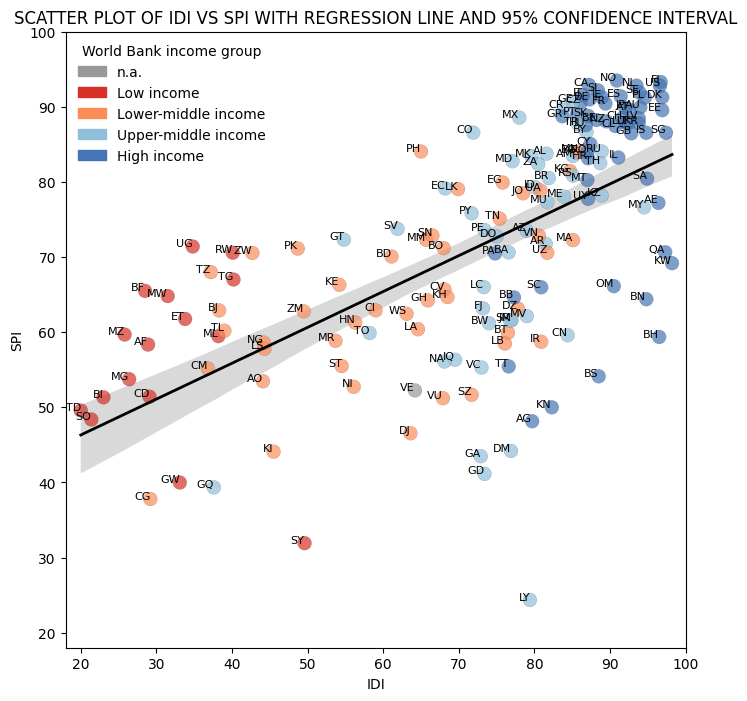

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Define your columns
x_column = 'idi'
y_column = 'spi'
label_column = 'iso2'
color_column = 'world_bank_income_group_numeric'


# Assign a color to each income group
group_colors = {
    'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower-middle income': '#fc8d59',
    'Upper-middle income': '#91bfdb',
    'High income': '#4575b4'
}
df['group_color'] = df['world_bank_income_group_2023_july'].map(group_colors)

# Start plotting
plt.figure(figsize=(8, 8))

# Draw regression line without scatter
sns.regplot(
    x=x_column, y=y_column,
    data=df,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)

# Scatter plot with manually assigned colors
plt.scatter(
    df[x_column], df[y_column],
    c=df['group_color'],
    s=100, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
for i, label in enumerate(df[label_column]):
    plt.text(df[x_column].iloc[i], df[y_column].iloc[i], label, fontsize=8, ha='right')

# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

# Add axis labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())
plt.title(f'Scatter plot of {x_column.upper()} vs {y_column.upper()} with regression line and 95% confidence interval'.upper())

plt.xlim(18, 100)
plt.ylim(18, 100)

plt.show()


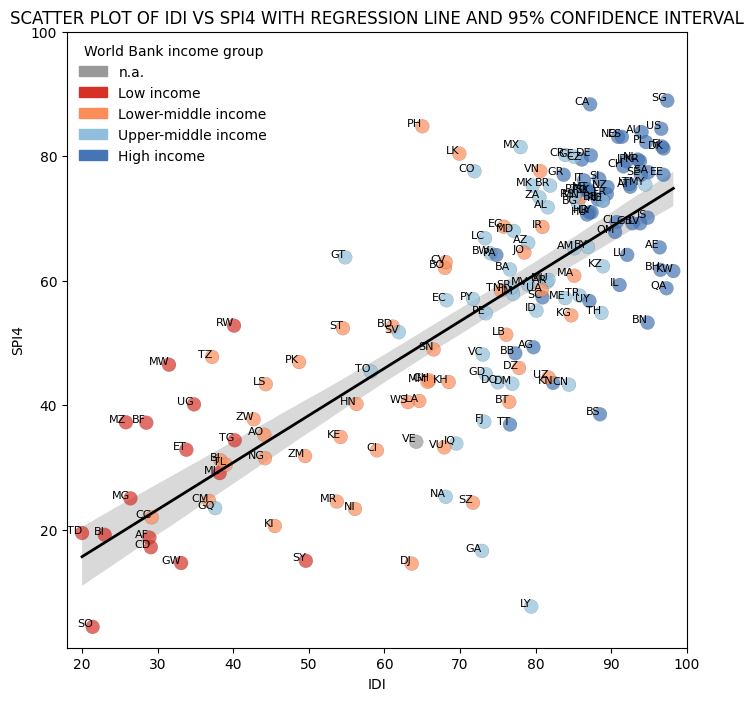

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Define your columns
x_column = 'idi'
y_column = 'spi4'
label_column = 'iso2'
color_column = 'world_bank_income_group_numeric'


# Assign a color to each income group
group_colors = {
    'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower-middle income': '#fc8d59',
    'Upper-middle income': '#91bfdb',
    'High income': '#4575b4'
}
df['group_color'] = df['world_bank_income_group_2023_july'].map(group_colors)

# Start plotting
plt.figure(figsize=(8, 8))

# Draw regression line without scatter
sns.regplot(
    x=x_column, y=y_column,
    data=df,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)

# Scatter plot with manually assigned colors
plt.scatter(
    df[x_column], df[y_column],
    c=df['group_color'],
    s=100, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
for i, label in enumerate(df[label_column]):
    plt.text(df[x_column].iloc[i], df[y_column].iloc[i], label, fontsize=8, ha='right')

# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

# Add axis labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())
plt.title(f'Scatter plot of {x_column.upper()} vs {y_column.upper()} with regression line and 95% confidence interval'.upper())

plt.xlim(18, 100)
plt.ylim(1, 100)

plt.show()


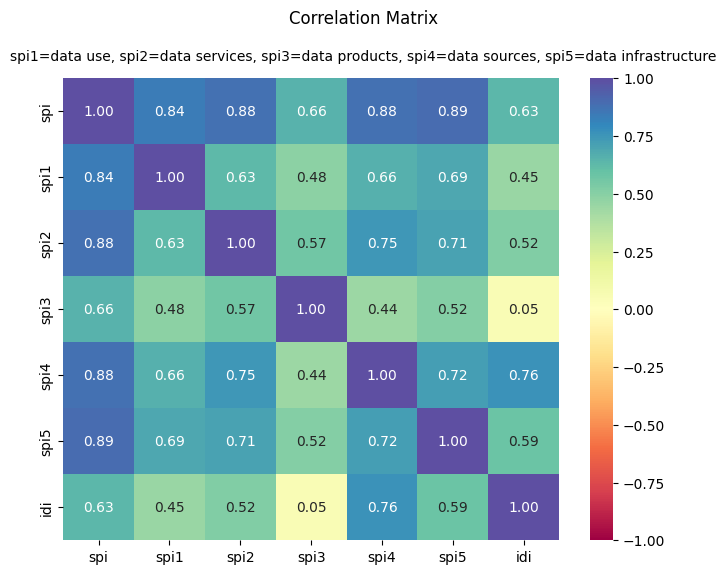

In [11]:
# Select the columns you want to include
columns_of_interest = ['spi','spi1', 'spi2', 'spi3', 'spi4', 'spi5','idi']
corr_matrix = df[columns_of_interest].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,         # show the correlation coefficients
    fmt=".2f",          # format numbers
    cmap='Spectral',    # diverging color map
    vmin=-1, vmax=1     # fix color range
)
plt.suptitle('Correlation Matrix', va='center')
#plt.title('spi1=data use, spi2=data services, spi3=data products, spi4=data sources, spi5=data infrastructure', va='center', fontsize=10)
plt.figtext(0.5, 0.91, 'spi1=data use, spi2=data services, spi3=data products, spi4=data sources, spi5=data infrastructure',
            ha='center', fontsize=10)

plt.show()

In [12]:
from scipy.stats import pearsonr

# Drop rows with NaNs in the relevant columns
clean_df = df[['idi', 'spi']].dropna()

corr_coef, p_value = pearsonr(clean_df['idi'], clean_df['spi'])
print(f'Correlation coefficient: {corr_coef:.3f}')
print(f'P-value: {p_value:.3e}')

Correlation coefficient: 0.635
P-value: 1.242e-19


In [13]:
from scipy.stats import pearsonr

# Drop rows with NaNs in the relevant columns
clean_df = df[['idi', 'spi4']].dropna()

corr_coef, p_value = pearsonr(clean_df['idi'], clean_df['spi4'])
print(f'Correlation coefficient: {corr_coef:.3f}')
print(f'P-value: {p_value:.3e}')

Correlation coefficient: 0.760
P-value: 8.370e-32


In [14]:
# redo analysis but without the EU

df_no_eu = df[df.eu != 'x'].copy()

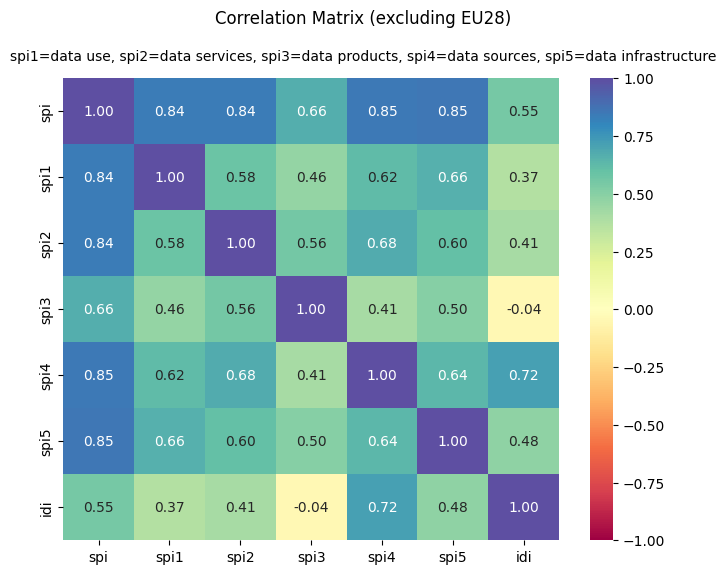

In [15]:
# Select the columns you want to include
columns_of_interest = ['spi','spi1', 'spi2', 'spi3', 'spi4', 'spi5','idi']
corr_matrix = df_no_eu[columns_of_interest].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,         # show the correlation coefficients
    fmt=".2f",          # format numbers
    cmap='Spectral',    # diverging color map
    vmin=-1, vmax=1     # fix color range
)

plt.suptitle('Correlation Matrix (excluding EU28)', va='center')

plt.figtext(0.5, 0.91, 'spi1=data use, spi2=data services, spi3=data products, spi4=data sources, spi5=data infrastructure',
            ha='center', fontsize=10)

plt.show()

In [16]:
from scipy.stats import pearsonr

# Drop rows with NaNs in the relevant columns
clean_df = df_no_eu[['idi', 'spi']].dropna()

corr_coef, p_value = pearsonr(clean_df['idi'], clean_df['spi'])
print(f'Correlation coefficient: {corr_coef:.3f}')
print(f'P-value: {p_value:.3e}')

Correlation coefficient: 0.550
P-value: 6.075e-12


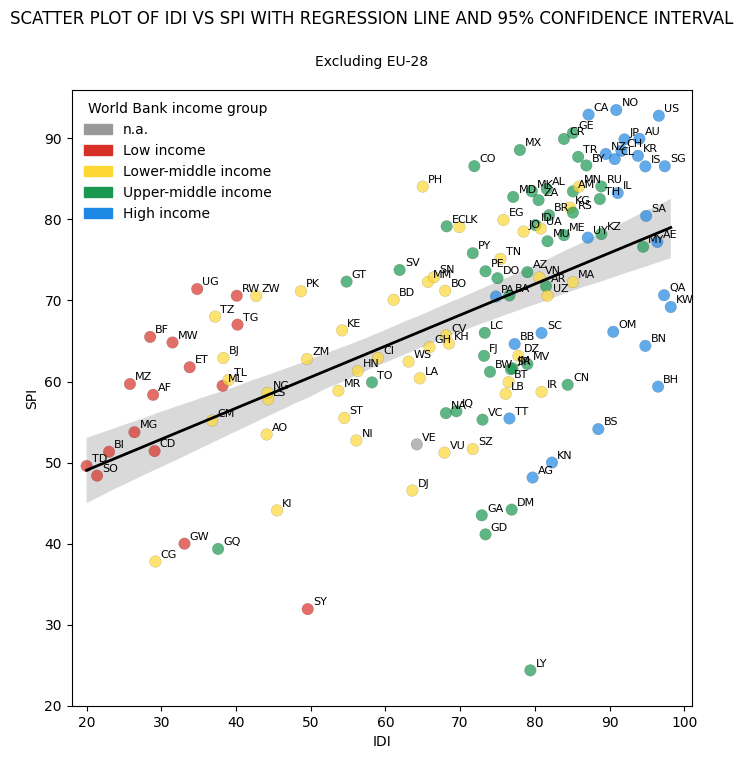

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# Define your columns
x_column = 'idi'
y_column = 'spi'
label_column = 'iso2'
color_column = 'world_bank_income_group_numeric'


# Assign a color to each income group
group_colors = {
    'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower-middle income': '#fdd835',
    'Upper-middle income': '#1a9850',
    'High income': '#1e88e5'
}
df_no_eu['group_color'] = df_no_eu['world_bank_income_group_2023_july'].map(group_colors)

# Start plotting
plt.figure(figsize=(8, 8))

# Draw regression line without scatter
sns.regplot(
    x=x_column, y=y_column,
    data=df_no_eu,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)

# Scatter plot with manually assigned colors
plt.scatter(
    df_no_eu[x_column], df_no_eu[y_column],
    c=df_no_eu['group_color'],
    s=70, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
for i, label in enumerate(df_no_eu[label_column]):
    plt.text(df_no_eu[x_column].iloc[i]+0.7, df_no_eu[y_column].iloc[i]+0.5, label, fontsize=8)

# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

# Add axis labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())
plt.suptitle(f'Scatter plot of {x_column.upper()} vs {y_column.upper()} with regression line and 95% confidence interval'.upper())
plt.figtext(0.5, 0.91, 'Excluding EU-28',
            ha='center', fontsize=10)

plt.xlim(18, 101)
plt.ylim(20, 96)

plt.show()


In [18]:
df_low = df[(df.world_bank_income_group_numeric == 2) & (df.iso3 != 'SYR')]
#df_low = df[(df.world_bank_income_group_numeric == 5)]

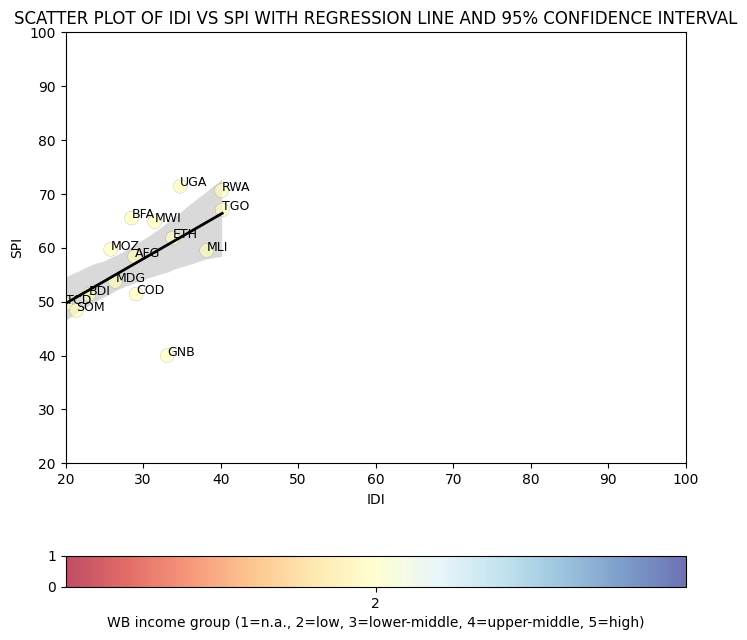

In [19]:
x_column = 'idi'  # replace with your column name
y_column = 'spi'  # replace with your column name
label_column = 'iso3'  # replace with your label column
color_column = 'world_bank_income_group_numeric'  # replace with the column for colors, has to be numeric

# First, draw the scatter plot using seaborn to include the regression line
plt.figure(figsize=(8, 8))
sns.regplot(
    x=x_column, y=y_column,
    data=df_low,
    scatter=False,
    color='black',    # Regression line color
    line_kws={'linewidth': 2}  # Optional: make the line thicker
)

# Overlay your original scatter plot
scatter = plt.scatter(
    df_low[x_column], df_low[y_column],
    c=df_low[color_column],
    cmap='RdYlBu',
    s=100, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Color bar with integer ticks
cbar = plt.colorbar(scatter, label='WB income group (1=n.a., 2=low, 3=lower-middle, 4=upper-middle, 5=high)', orientation='horizontal')
cbar.set_ticks(range(int(df_low[color_column].min()), int(df_low[color_column].max()) + 1))
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Add point labels
for i, label in enumerate(df_low[label_column]):
    plt.text(df_low[x_column].iloc[i], df_low[y_column].iloc[i], label, fontsize=9, ha='left')

# Uppercase labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())
plt.title(f'Scatter plot of {x_column.upper()} vs {y_column.upper()} with regression line and 95% confidence interval'.upper())

plt.xlim(20, 100)
plt.ylim(20, 100)

plt.show()


In [25]:
df[df['world_bank_income_group_2023_july']=='n.a.']

,iso3,itud_region,world_bank_income_group_2023_july,economy,idi,spi,spi4,spi1,spi2,spi3,spi5,eu,internet_users,world_bank_income_group_numeric,iso2,group_color
165,VEN,The Americas,n.a.,Venezuela,64.2,52.25,34.1,80.0,59.9,62.25,25.0,NaN,NaN,1,VE,#999999


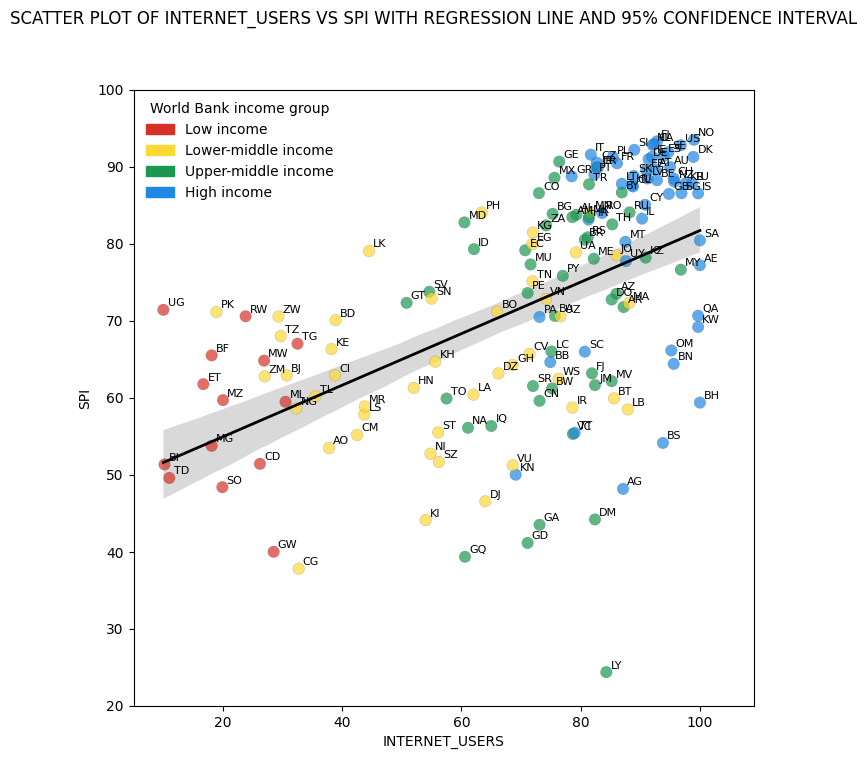

In [27]:

# Define your columns
x_column = 'internet_users'
y_column = 'spi'
label_column = 'iso2'
color_column = 'world_bank_income_group_numeric'
df = df[df['world_bank_income_group_2023_july']!='n.a.']


# Assign a color to each income group
group_colors = {
    #'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower-middle income': '#fdd835',
    'Upper-middle income': '#1a9850',
    'High income': '#1e88e5'
}
df['group_color'] = df['world_bank_income_group_2023_july'].map(group_colors)

# Start plotting
plt.figure(figsize=(8, 8))

# Draw regression line without scatter
sns.regplot(
    x=x_column, y=y_column,
    data=df,
    scatter=False,
    color='black',
    line_kws={'linewidth': 2}
)

# Scatter plot with manually assigned colors
plt.scatter(
    df[x_column], df[y_column],
    c=df['group_color'],
    s=70, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
for i, label in enumerate(df[label_column]):
    plt.text(df[x_column].iloc[i]+0.7, df[y_column].iloc[i]+0.5, label, fontsize=8)

# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

# Add axis labels and title
plt.xlabel(x_column.upper())
plt.ylabel(y_column.upper())
plt.suptitle(f'Scatter plot of {x_column.upper()} vs {y_column.upper()} with regression line and 95% confidence interval'.upper())
plt.figtext(0.5, 0.91, '',
            ha='center', fontsize=10)

plt.xlim(5, 109)
plt.ylim(20, 100)

plt.show()


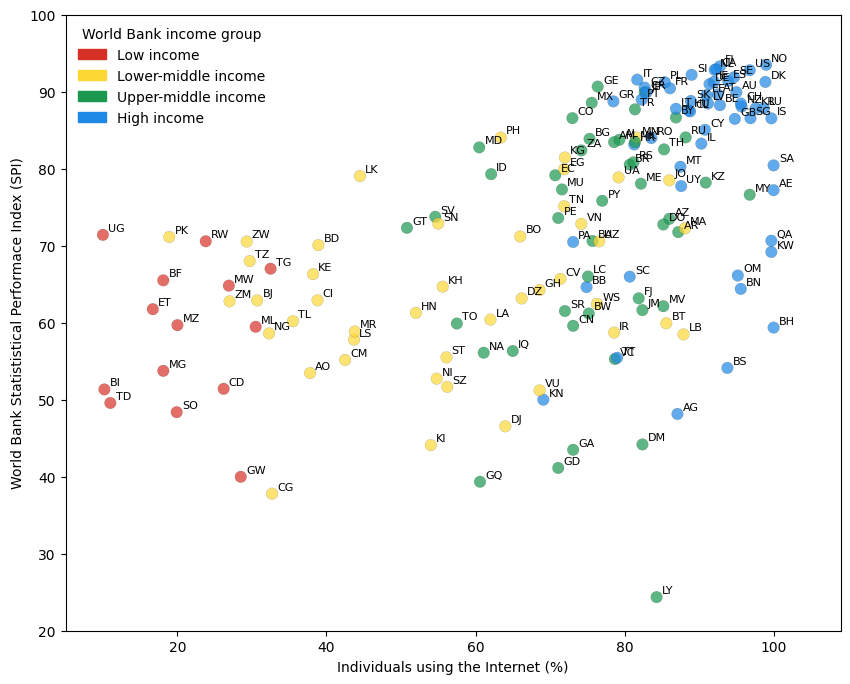

In [33]:

# Define your columns
x_column = 'internet_users'
y_column = 'spi'
label_column = 'iso2'
color_column = 'world_bank_income_group_numeric'
df = df[df['world_bank_income_group_2023_july']!='n.a.']


# Assign a color to each income group
group_colors = {
    #'n.a.': '#999999',
    'Low income': '#d73027',
    'Lower-middle income': '#fdd835',
    'Upper-middle income': '#1a9850',
    'High income': '#1e88e5'
}
df['group_color'] = df['world_bank_income_group_2023_july'].map(group_colors)

# Start plotting
plt.figure(figsize=(10, 8))


# Scatter plot with manually assigned colors
plt.scatter(
    df[x_column], df[y_column],
    c=df['group_color'],
    s=70, edgecolors='k', linewidths=0.1, alpha=0.7
)

# Add point labels
for i, label in enumerate(df[label_column]):
    plt.text(df[x_column].iloc[i]+0.7, df[y_column].iloc[i]+0.5, label, fontsize=8)

# Add legend
patches = [mpatches.Patch(color=color, label=label) for label, color in group_colors.items()]
plt.legend(handles=patches, title='World Bank income group', frameon=False)

# Add axis labels and title
plt.xlabel('Individuals using the Internet (%)')
plt.ylabel('World Bank Statististical Performace Index (SPI)')
#plt.suptitle(f'Scatter plot of {x_column.upper()} vs {y_column.upper()}'.upper())
plt.figtext(0.5, 0.91, '',
            ha='center', fontsize=10)

plt.xlim(5, 109)
plt.ylim(20, 100)

plt.show()
